# Imports

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# Euclidean Distance

In [12]:
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

# Average Linkage Distance

In [14]:
def average_linkage_distance(cluster1, cluster2, data):

    distances = []

    for i in cluster1:
        for j in cluster2:

            dist = euclidean_distance(data[i], data[j])
            distances.append(dist)

    return sum(distances) / len(distances)

# Function to Print Distance Matrix

In [16]:
def print_distance_matrix(clusters, data):

    keys = list(clusters.keys())

    matrix = []

    for i in keys:
        row = []
        for j in keys:

            if i == j:
                row.append(0)
            else:
                dist = average_linkage_distance(clusters[i], clusters[j], data)
                row.append(round(dist,2))

        matrix.append(row)

    labels = [str(tuple(clusters[k])) for k in keys]

    df = pd.DataFrame(matrix, index=labels, columns=labels)

    print("\nDistance Matrix")
    print(df)

# Average Linkage

In [22]:
def average_linkage(data):

    n = len(data)

    clusters = {i:[i] for i in range(n)}

    next_cluster_id = n
    linkage_matrix = []

    step = 1

    while len(clusters) > 1:

        print(f"\n========== STEP {step} ==========")

        print_distance_matrix(clusters, data)

        keys = list(clusters.keys())

        min_dist = float("inf")
        pair = None

        for i in range(len(keys)):
            for j in range(i+1,len(keys)):

                c1 = clusters[keys[i]]
                c2 = clusters[keys[j]]

                dist = average_linkage_distance(c1, c2, data)

                if dist < min_dist:
                    min_dist = dist
                    pair = (keys[i],keys[j])

        c1,c2 = pair

        new_cluster = clusters[c1] + clusters[c2]

        row = [c1,c2,min_dist,len(new_cluster)]
        linkage_matrix.append(row)

        print(f"\nMerging clusters {clusters[c1]} and {clusters[c2]}")
        print(f"Distance = {round(min_dist,2)}")

        del clusters[c1]
        del clusters[c2]

        clusters[next_cluster_id] = new_cluster
        next_cluster_id += 1

        step += 1

    return np.array(linkage_matrix)

# Dataset

In [25]:
data = np.array([
    [1,2],
    [2,3],
    [8,8],
    [9,10],
    [25,30]
])

In [27]:
Z = average_linkage(data)

print("\nFinal Linkage Matrix")
print(Z)


========== STEP 1 ==========

Distance Matrix
       (0,)   (1,)   (2,)   (3,)   (4,)
(0,)   0.00   1.41   9.22  11.31  36.88
(1,)   1.41   0.00   7.81   9.90  35.47
(2,)   9.22   7.81   0.00   2.24  27.80
(3,)  11.31   9.90   2.24   0.00  25.61
(4,)  36.88  35.47  27.80  25.61   0.00

Merging clusters [0] and [1]
Distance = 1.41

========== STEP 2 ==========

Distance Matrix
         (2,)   (3,)   (4,)  (0, 1)
(2,)     0.00   2.24  27.80    8.51
(3,)     2.24   0.00  25.61   10.61
(4,)    27.80  25.61   0.00   36.17
(0, 1)   8.51  10.61  36.17    0.00

Merging clusters [2] and [3]
Distance = 2.24

========== STEP 3 ==========

Distance Matrix
         (4,)  (0, 1)  (2, 3)
(4,)     0.00   36.17   26.71
(0, 1)  36.17    0.00    9.56
(2, 3)  26.71    9.56    0.00

Merging clusters [0, 1] and [2, 3]
Distance = 9.56

========== STEP 4 ==========

Distance Matrix
               (4,)  (0, 1, 2, 3)
(4,)           0.00         31.44
(0, 1, 2, 3)  31.44          0.00

Merging clusters [4] and 

# Maximum Height of Dendrogram

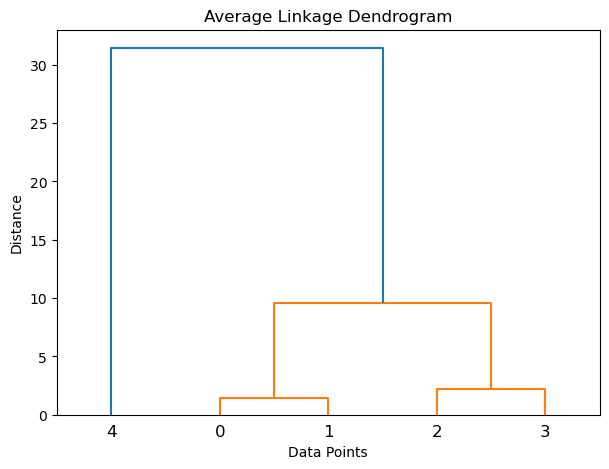


Maximum Dendrogram Height: 31.440462007438757


In [30]:
plt.figure(figsize=(7,5))

dendrogram(Z)

plt.title("Average Linkage Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

max_height = np.max(Z[:,2])

print("\nMaximum Dendrogram Height:", max_height)